In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans,DBSCAN
from sklearn.preprocessing import StandardScaler

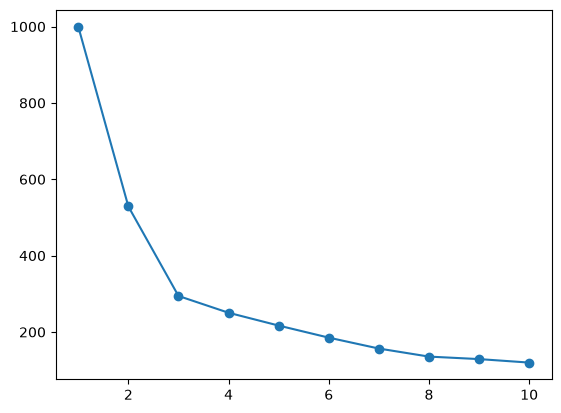

In [2]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(K_range, inertia, marker='o')

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

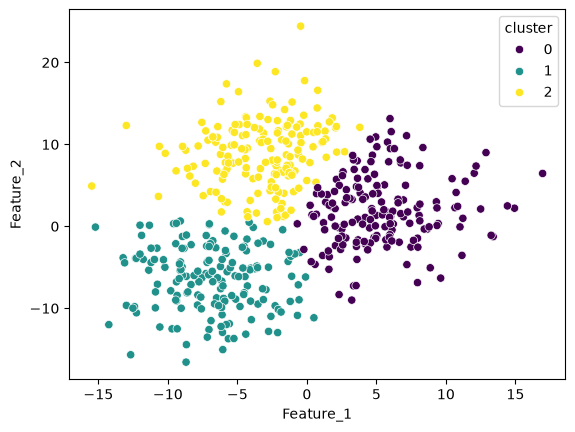

In [16]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df['cluster'] = cluster_labels
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette='viridis')

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

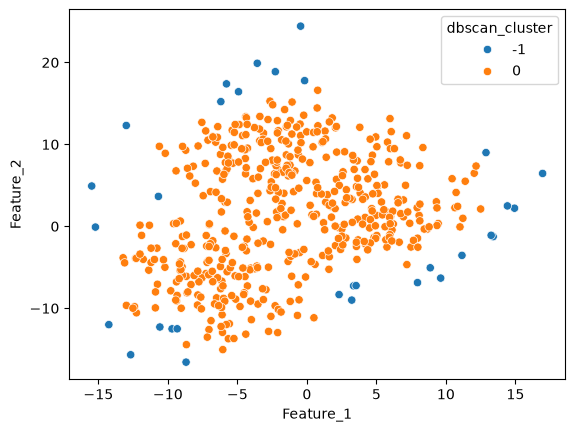

In [17]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['dbscan_cluster'] = dbscan_labels
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

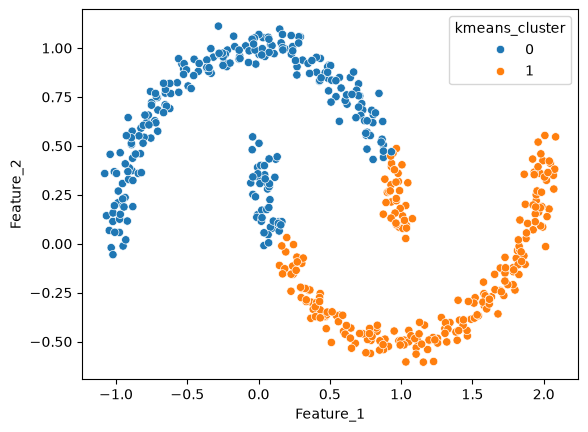

In [18]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_moons
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'] = kmeans_labels
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')



<Axes: xlabel='Feature_1', ylabel='Feature_2'>

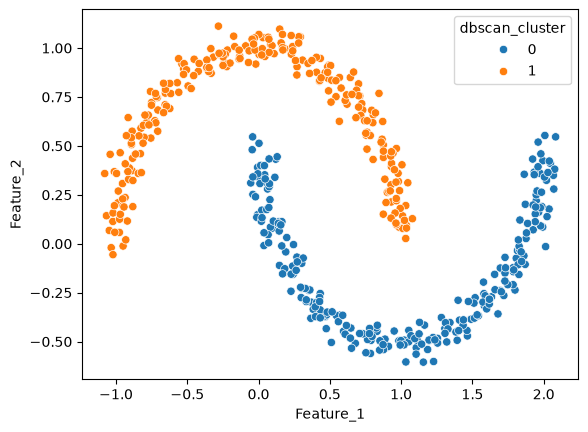

In [19]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['dbscan_cluster'] = dbscan_labels
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')


PCA

<Axes: xlabel='PC1', ylabel='PC2'>

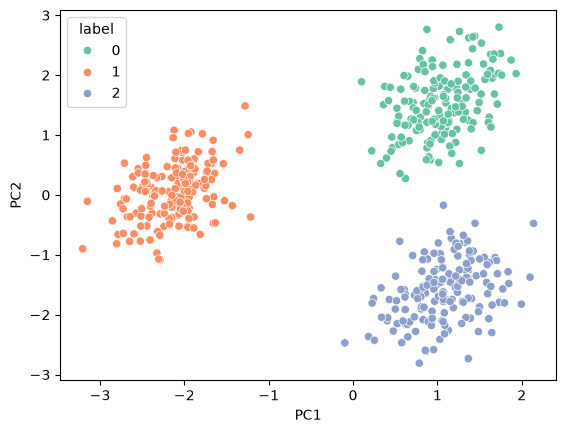

In [ ]:
from sklearn.decomposition import PCA
X, y = make_blobs(n_samples=500, n_features=5, centers=3, cluster_std=1.5, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) # now 2 only fetures
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='label', palette='Set2')